<a href="https://colab.research.google.com/github/thisisgsn-cpu/northstar-analytics-project/blob/main/03_python_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install pandas numpy matplotlib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("All Python libraries loaded successfully")

All Python libraries loaded successfully


In [2]:
!git clone https://github.com/thisisgsn-cpu/northstar-analytics-project.git

Cloning into 'northstar-analytics-project'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 36 (delta 9), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 104.22 KiB | 1.63 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [4]:
orders = pd.read_csv("/content/northstar-analytics-project/data/orders.csv")

deliveries = pd.read_csv("/content/northstar-analytics-project/data/deliveries.csv")

customers = pd.read_csv("/content/northstar-analytics-project/data/customers.csv")

drivers = pd.read_csv("/content/northstar-analytics-project/data/drivers.csv")

vehicles = pd.read_csv("/content/northstar-analytics-project/data/vehicles.csv")

complaints = pd.read_csv("/content/northstar-analytics-project/data/complaints.csv")

app_events = pd.read_csv("/content/northstar-analytics-project/data/app_events.csv")

print("All operational datasets loaded successfully")

All operational datasets loaded successfully


In [7]:
print(orders.head())

print(deliveries.head())

print(customers.head())

print(orders.info())

print(deliveries.info())

print(customers.info())

  order_id customer_id service_type     order_created_at  \
0   O00001       C0292    Passenger  2024-08-20 14:43:00   
1   O00002       C0459    Passenger  2024-05-14 22:16:00   
2   O00003       C0161    Passenger  2025-09-02 14:37:00   
3   O00004       C0520       Parcel  2025-01-11 17:15:00   
4   O00005       C0558       Retail  2025-02-17 19:32:00   

   promised_window_hours pickup_zone dropoff_zone priority_level  order_value  \
0                      6     Airport        South         Medium       126.65   
1                     24       North      AIRPORT            Low       109.30   
2                      4        West      AIRPORT           High        33.50   
3                      2   RiverSide        North         Medium        10.04   
4                     12   Riverside        SOUTH            Low       125.58   

  booking_channel  special_handling_flag  
0             App                      0  
1             App                      0  
2           Phone      

In [8]:
orders["pickup_zone"] = orders["pickup_zone"].str.upper()

orders["dropoff_zone"] = orders["dropoff_zone"].str.upper()

deliveries["delivery_status"] = deliveries["delivery_status"].str.upper()

customers["preferred_channel"] = customers["preferred_channel"].fillna("UNKNOWN")

print("Operational data cleaning completed successfully")

Operational data cleaning completed successfully


In [9]:
print(orders.isnull().sum())

print(deliveries.isnull().sum())

print(customers.isnull().sum())

print(complaints.isnull().sum())

order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred

In [10]:
delivery_analysis = deliveries.groupby(
    "delivery_status"
).agg(

    total_deliveries = (
        "delivery_id",
        "count"
    ),

    average_route_distance = (
        "route_distance_km",
        "mean"
    ),

    average_operational_cost = (
        "fuel_or_charge_cost",
        "mean"
    ),

    average_customer_rating = (
        "customer_rating_post_delivery",
        "mean"
    )

).reset_index()

print(delivery_analysis)

  delivery_status  total_deliveries  average_route_distance  \
0         DELAYED               202               14.670248   
1          FAILED               132               13.365303   
2          ONTIME               616               13.776364   

   average_operational_cost  average_customer_rating  
0                 13.138713                 3.114975  
1                 13.147955                 3.049313  
2                 12.678052                 4.283273  


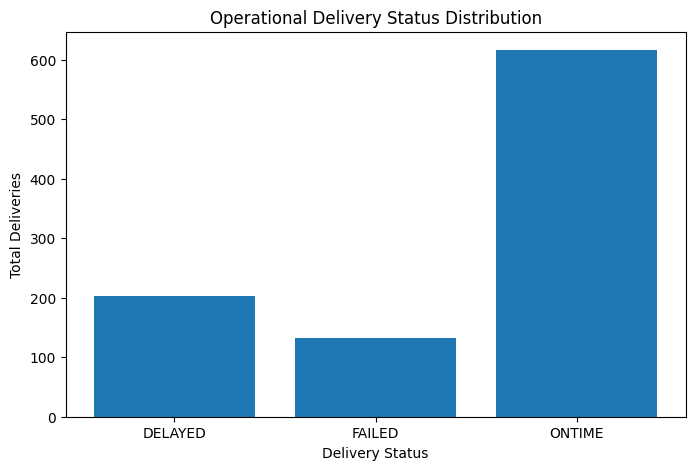

In [11]:
plt.figure(figsize = (8,5))

plt.bar(
    delivery_analysis["delivery_status"],
    delivery_analysis["total_deliveries"]
)

plt.title("Operational Delivery Status Distribution")

plt.xlabel("Delivery Status")

plt.ylabel("Total Deliveries")

plt.show()

In [12]:
vehicle_analysis = deliveries.merge(
    vehicles,
    on = "vehicle_id"
)

vehicle_performance = vehicle_analysis.groupby(
    "maintenance_status"
).agg(

    average_battery_health = (
        "battery_health_pct",
        "mean"
    ),

    average_operational_cost = (
        "fuel_or_charge_cost",
        "mean"
    ),

    average_customer_rating = (
        "customer_rating_post_delivery",
        "mean"
    ),

    total_deliveries = (
        "delivery_id",
        "count"
    )

).reset_index()

print(vehicle_performance)

  maintenance_status  average_battery_health  average_operational_cost  \
0             Active               76.561896                 12.872103   
1           InRepair               76.725984                 12.904567   
2          Scheduled               78.735714                 12.628506   

   average_customer_rating  total_deliveries  
0                 3.953539               542  
1                 3.634080               254  
2                 3.931776               154  


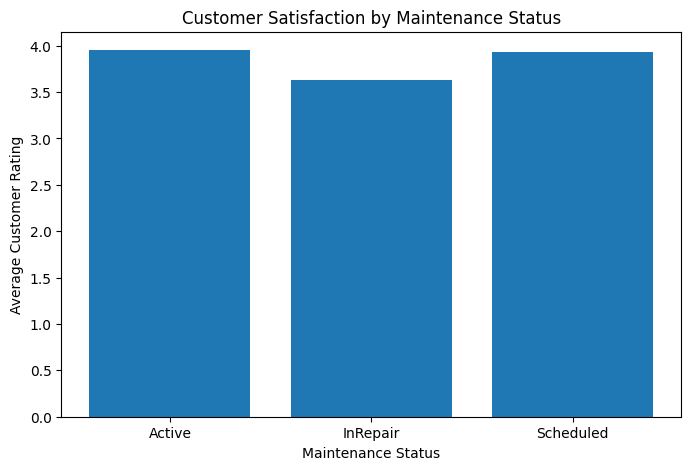

In [13]:
plt.figure(figsize = (8,5))

plt.bar(
    vehicle_performance["maintenance_status"],
    vehicle_performance["average_customer_rating"]
)

plt.title("Customer Satisfaction by Maintenance Status")

plt.xlabel("Maintenance Status")

plt.ylabel("Average Customer Rating")

plt.show()

In [14]:
complaint_analysis = complaints.groupby(
    "severity"
).agg(

    total_complaints = (
        "complaint_id",
        "count"
    ),

    average_resolution_days = (
        "resolution_days",
        "mean"
    ),

    average_compensation = (
        "compensation_amount",
        "mean"
    )

).reset_index()

print(complaint_analysis)

  severity  total_complaints  average_resolution_days  average_compensation
0     High                77                13.116883             38.847941
1      Low                71                 6.563380              9.056000
2   Medium               172                 6.168605             17.365120


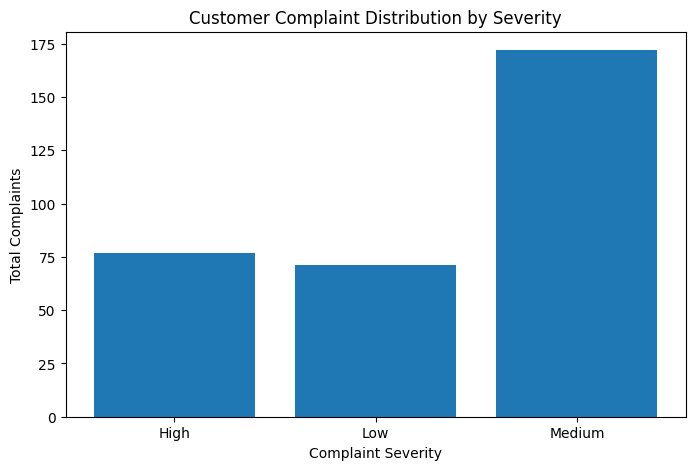

In [15]:
plt.figure(figsize = (8,5))

plt.bar(
    complaint_analysis["severity"],
    complaint_analysis["total_complaints"]
)

plt.title("Customer Complaint Distribution by Severity")

plt.xlabel("Complaint Severity")

plt.ylabel("Total Complaints")

plt.show()

In [16]:
app_analysis = app_events.groupby(
    "device_type"
).agg(

    average_api_latency = (
        "api_latency_ms",
        "mean"
    ),

    successful_events = (
        "success_flag",
        "sum"
    ),

    total_events = (
        "event_id",
        "count"
    )

).reset_index()

print(app_analysis)

  device_type  average_api_latency  successful_events  total_events
0     Android           464.898413                294           315
1         Web           474.684783                 86            92
2         iOS           463.145923                222           233


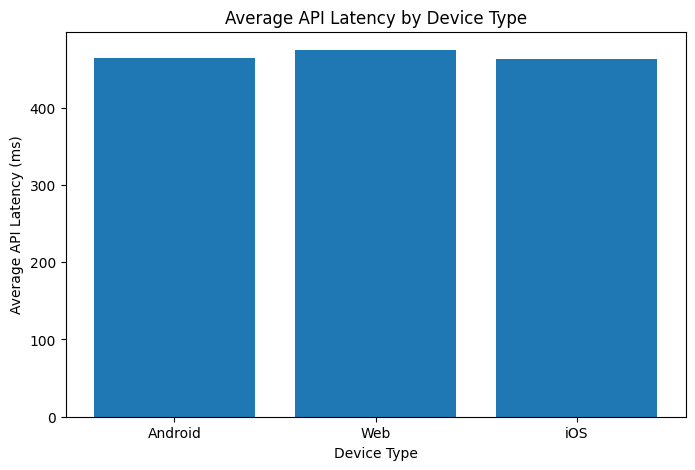

In [17]:
plt.figure(figsize = (8,5))

plt.bar(
    app_analysis["device_type"],
    app_analysis["average_api_latency"]
)

plt.title("Average API Latency by Device Type")

plt.xlabel("Device Type")

plt.ylabel("Average API Latency (ms)")

plt.show()

In [7]:
correlation_analysis = deliveries[[
    "route_distance_km",
    "fuel_or_charge_cost",
    "customer_rating_post_delivery",
    "manual_route_override_count"
]].corr()

print(correlation_analysis)

                               route_distance_km  fuel_or_charge_cost  \
route_distance_km                       1.000000             0.524194   
fuel_or_charge_cost                     0.524194             1.000000   
customer_rating_post_delivery           0.028525            -0.059062   
manual_route_override_count             0.202296             0.098690   

                               customer_rating_post_delivery  \
route_distance_km                                   0.028525   
fuel_or_charge_cost                                -0.059062   
customer_rating_post_delivery                       1.000000   
manual_route_override_count                        -0.059903   

                               manual_route_override_count  
route_distance_km                                 0.202296  
fuel_or_charge_cost                               0.098690  
customer_rating_post_delivery                    -0.059903  
manual_route_override_count                       1.000000  


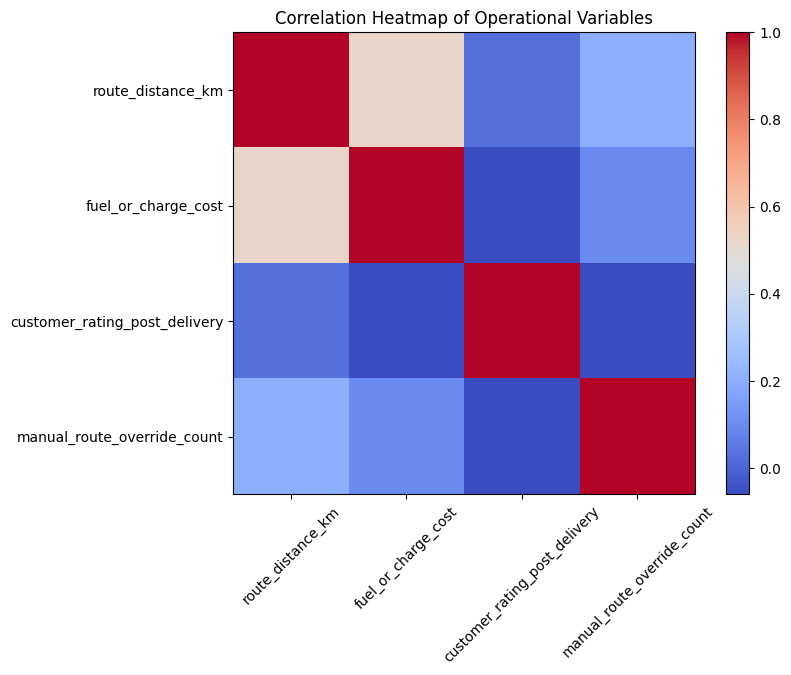

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8,6))

plt.imshow(
    correlation_analysis,
    cmap = "coolwarm",
    interpolation = "nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_analysis.columns)),
    correlation_analysis.columns,
    rotation = 45
)

plt.yticks(
    range(len(correlation_analysis.columns)),
    correlation_analysis.columns
)

plt.title("Correlation Heatmap of Operational Variables")

plt.show()